In [1]:
import pandas as pd

df = pd.read_csv("Superstore.csv", encoding='latin1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [4]:
df['Price'] = df['Sales'] / df['Quantity']

In [5]:
df[['Product Name', 'Quantity', 'Sales', 'Price']].head()

,Product Name,Quantity,Sales,Price
0,Bush Somerset Collection Bookcase,2,261.9600,130.9800
1,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",3,731.9400,243.9800
2,Self-Adhesive Address Labels for Typewriters b...,2,14.6200,7.3100
3,Bretford CR4500 Series Slim Rectangular Table,5,957.5775,191.5155
4,Eldon Fold 'N Roll Cart System,2,22.3680,11.1840


# Price Calculation

Since price was not directly available, it was derived by dividing sales by quantity for each transaction.

In [6]:
top_skus = df['Product Name'].value_counts().head(10)
top_skus

Product Name
Staple envelope                                              48
Easy-staple paper                                            46
Staples                                                      46
Avery Non-Stick Binders                                      20
Staples in misc. colors                                      19
Staple remover                                               18
KI Adjustable-Height Table                                   18
Storex Dura Pro Binders                                      17
Staple-based wall hangings                                   16
Logitech 910-002974 M325 Wireless Mouse for Web Scrolling    15
Name: count, dtype: int64

# SKU Selection

1. Staple envelope (high frequency)
2. Easy-staple paper (similar category, good comparison)
3. Logitech Wireless Mouse (different category, higher price range)

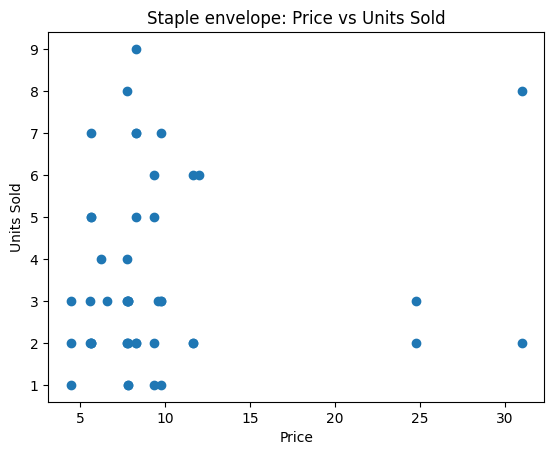

In [7]:
import matplotlib.pyplot as plt

sku1 = df[df['Product Name'] == 'Staple envelope']

plt.scatter(sku1['Price'], sku1['Quantity'])
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Staple envelope: Price vs Units Sold")
plt.show()

# Price vs Sales Observation (Staple Envelope)

The scatter plot shows that most sales occur within a lower price range, with higher variability in units sold. At higher price points, the number of units sold tends to be lower, indicating a mild negative relationship between price and demand. However, the relationship is not strongly consistent, suggesting limited price sensitivity.

Elasticity Tag

This product is: Moderately price-sensitive (weak elasticity)

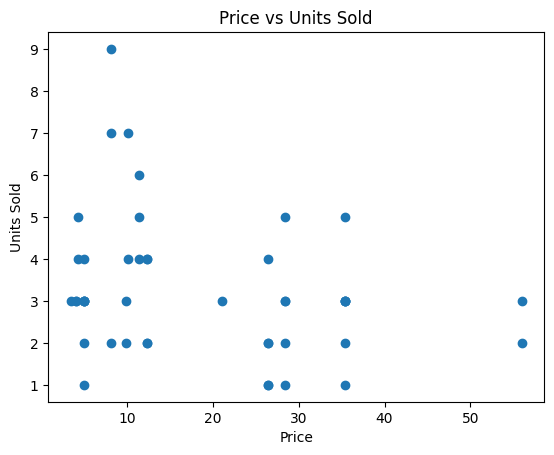

In [8]:
sku2 = df[df['Product Name'] == 'Easy-staple paper']

plt.scatter(sku2['Price'], sku2['Quantity'])
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()

# Price vs Sales Observation (Easy-staple Paper)

The scatter plot shows that higher sales occur primarily at lower price points. As price increases, units sold consistently decrease, with no high-volume sales observed at higher prices. This indicates a clear inverse relationship between price and demand.

Elasticity Tag

This product is: Highly price-sensitive (elastic)

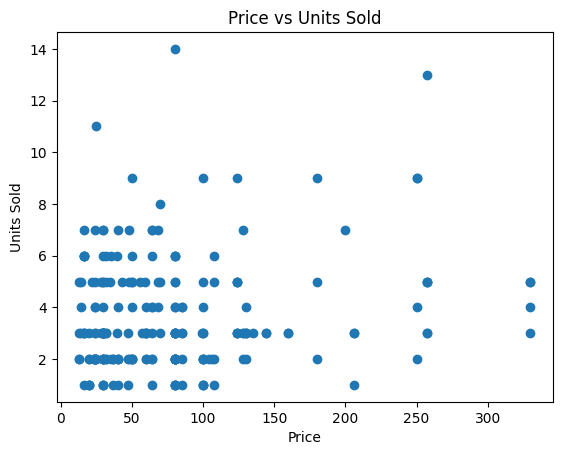

In [9]:
sku3 = df[df['Product Name'].str.contains('Logitech')]

plt.scatter(sku3['Price'], sku3['Quantity'])
plt.xlabel("Price")
plt.ylabel("Units Sold")
plt.title("Price vs Units Sold")
plt.show()


# Price vs Sales Observation (Logitech Wireless Mouse)

The scatter plot shows a wide price range with no consistent decline in units sold at higher prices. Sales remain distributed across both low and high price points, indicating a weak relationship between price and demand.

Elasticity Tag

This product is: Price-insensitive (inelastic)

# Elasticity Comparison

- Easy-staple paper shows strong price sensitivity, with demand decreasing as price increases.
- Staple envelope shows mild price sensitivity, with some variation in demand across price levels.
- Logitech Wireless Mouse shows low price sensitivity, with demand relatively stable across a wide price range.

# Pricing Strategy

Easy-staple paper:

    Since sales drop consistently at higher prices, even small price increases can reduce demand. A low-margin, high-volume strategy with frequent small discounts can maximize total sales.

Staple envelope:

    Demand varies across similar price points, suggesting factors other than price also influence sales. A stable pricing strategy with targeted promotions during low-demand periods would be more effective than constant discounting.

Logitech Wireless Mouse:

    Sales remain relatively stable across a wide price range, indicating customers are less price-sensitive. This allows for a value-based pricing approach, where pricing can be optimized based on features or brand positioning rather than cost.